# 🏆 Lab 2: 보상 함수의 힘 — 같은 AI, 다른 행동 (30분)

## 학습 목표
1. **보상 함수가 AI의 행동을 결정**한다는 것을 실험으로 확인한다
2. 같은 환경 + 같은 알고리즘인데 **보상만 바꿔도** 행동이 완전히 달라짐을 관찰한다
3. 보상 설계의 중요성을 체감하고, 자율주행 시뮬레이터에 연결한다

## 핵심 질문
> "같은 미로에서 같은 Q-Learning을 쓰는데,  
> 보상 함수를 바꾸면 에이전트의 행동이 달라질까?"

**→ 달라집니다! 그것도 극적으로!**


## 1단계: 환경 설정

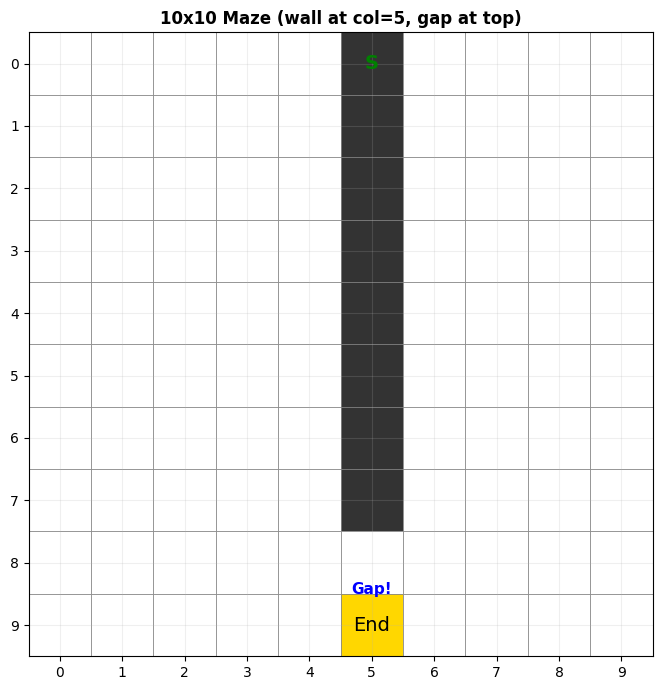

환경: 10×10 미로
  시작: (0, 5) → 목표: (9, 5)
  벽: 세로 벽 (col=5, row 0~7) — 위쪽(row 8~9)에 틈
  에이전트는 틈을 돌아서 목표에 도달해야 합니다


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

np.random.seed(42)

# ============================================
# 환경 정의: 10×10 미로 (Lab 1보다 복잡!)
# ============================================
GRID = 10
START = (0, 5)
GOAL = (9, 5)

# 벽: x=5 줄에 세로 벽, y≥8에 틈
WALLS = set()
for r in range(8):  # row 0~7에 벽
    WALLS.add((r, 5))

ACTION_DELTAS = [(-1,0), (1,0), (0,-1), (0,1)]  # 상하좌우
ACTION_ARROWS = ['↑', '↓', '←', '→']

def step_base(state, action):
    """기본 이동 (보상 없이 상태 전이만)"""
    r, c = state
    dr, dc = ACTION_DELTAS[action]
    nr, nc = r+dr, c+dc
    if nr<0 or nr>=GRID or nc<0 or nc>=GRID or (nr,nc) in WALLS:
        return state, True  # 충돌
    return (nr, nc), False

def draw_maze(ax, title="", policy=None, path=None, special_cells=None):
    ax.set_xlim(-0.5, GRID-0.5)
    ax.set_ylim(GRID-0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    for r in range(GRID):
        for c in range(GRID):
            color = 'white'
            if (r,c) in WALLS: color = '#333'
            elif (r,c) == GOAL: color = '#FFD700'
            elif (r,c) == START: color = '#90EE90'
            if special_cells and (r,c) in special_cells:
                color = special_cells[(r,c)]
            ax.add_patch(patches.Rectangle((c-0.5,r-0.5), 1, 1,
                         facecolor=color, edgecolor='gray', linewidth=0.5))
            
            if policy is not None and (r,c) not in WALLS and (r,c) != GOAL:
                ax.text(c, r, ACTION_ARROWS[policy[r,c]], 
                       ha='center', va='center', fontsize=9, fontweight='bold')
    
    if path:
        rows, cols = zip(*path)
        ax.plot(cols, rows, 'ro-', markersize=4, linewidth=2, alpha=0.7, zorder=5)
    
    ax.set_xticks(range(GRID))
    ax.set_yticks(range(GRID))
    ax.grid(True, alpha=0.2)

fig, ax = plt.subplots(figsize=(7, 7))
draw_maze(ax, "10x10 Maze (wall at col=5, gap at top)")
ax.text(5, 0, 'S', ha='center', va='center', fontsize=14, color='green', fontweight='bold', zorder=10)
ax.text(5, 9, 'End', ha='center', va='center', fontsize=14, zorder=10)
ax.annotate('Gap!', xy=(5, 8.5), fontsize=11, color='blue', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("환경: 10×10 미로")
print(f"  시작: {START} → 목표: {GOAL}")
print(f"  벽: 세로 벽 (col=5, row 0~7) — 위쪽(row 8~9)에 틈")
print(f"  에이전트는 틈을 돌아서 목표에 도달해야 합니다")


## 2단계: 보상 함수 3가지 정의

**같은 미로, 같은 Q-Learning, 같은 파라미터** — 오직 보상 함수만 다릅니다!

| 보상 함수 | 규칙 | 예상 행동 |
|-----------|------|----------|
| **A. 목표 도달** | 목표 +100, 이동 -0.1, 충돌 -1 | 최단 경로로 목표 도달 |
| **B. 조심스러운 주행** | 목표 +100, 벽 근처 -0.5, 진행 보상 | 벽에서 멀리 돌아가며 도달 |
| **C. 탐험 보상** | 새로운 칸 +3, 재방문 -0.5 | 최대한 많은 칸 방문하며 도달 |


In [3]:
# ============================================
# 보상 함수 3가지 정의
# ============================================

def reward_goal_oriented(state, next_state, hit_wall, visited):
    """A. 목표 도달 보상: 목표에 가면 큰 보상"""
    if next_state == GOAL:
        return 100
    if hit_wall:
        return -1
    return -0.1  # 이동 비용 → 빠른 도달 유도

def reward_wall_avoid(state, next_state, hit_wall, visited):
    """B. 조심스러운 주행: 목표 도달 + 벽 근처 회피"""
    if next_state == GOAL:
        return 100
    if hit_wall:
        return -5
    r, c = next_state
    progress = r / GRID * 0.3
    wall_penalty = -0.5 if abs(c - 5) <= 1 else 0
    return progress + wall_penalty - 0.05

def reward_exploration(state, next_state, hit_wall, visited):
    """C. 탐험 보상: 새로운 곳을 방문하면 보상"""
    if next_state == GOAL:
        return 50
    if hit_wall:
        return -1
    if next_state not in visited:
        return 3
    return -0.5

reward_functions = {
    "A. Goal-Oriented": reward_goal_oriented,
    "B. Cautious": reward_wall_avoid,
    "C. Exploration": reward_exploration,
}

print("✅ 보상 함수 3가지 정의 완료!")
for name in reward_functions:
    print(f"  • {name}")


✅ 보상 함수 3가지 정의 완료!
  • A. Goal-Oriented
  • B. Cautious
  • C. Exploration


## 3단계: 같은 Q-Learning으로 3가지 보상 함수 학습!

이제 **동일한 Q-Learning 알고리즘**에 서로 다른 보상 함수를 넣고 학습시킵니다.

결과가 어떻게 달라지는지 관찰합시다!


In [4]:
# ============================================
# Q-Learning 실행 (보상 함수별)
# ============================================
def train_q_learning(reward_fn, episodes=2000, alpha=0.1, gamma=0.95):
    Q = np.zeros((GRID, GRID, 4))
    ep_rewards = []
    ep_success = []
    
    for ep in range(episodes):
        state = START
        total_reward = 0
        epsilon = max(0.05, 0.5 - ep * 0.001)
        visited = {state}
        
        for _ in range(200):
            if np.random.rand() < epsilon:
                action = np.random.randint(4)
            else:
                action = np.argmax(Q[state[0], state[1]])
            
            next_state, hit_wall = step_base(state, action)
            reward = reward_fn(state, next_state, hit_wall, visited)
            done = (next_state == GOAL)
            visited.add(next_state)
            
            old_q = Q[state[0], state[1], action]
            next_max_q = np.max(Q[next_state[0], next_state[1]]) if not done else 0
            Q[state[0], state[1], action] = old_q + alpha * (
                reward + gamma * next_max_q - old_q)
            
            total_reward += reward
            state = next_state
            if done: break
        
        ep_rewards.append(total_reward)
        ep_success.append(done)
    
    return Q, ep_rewards, ep_success

# 3가지 보상 함수로 각각 학습
results = {}
for name, fn in reward_functions.items():
    print(f"학습 중: {name}...", end=" ")
    np.random.seed(42)
    Q, rewards, success = train_q_learning(fn)
    results[name] = {"Q": Q, "rewards": rewards, "success": success}
    last_100_success = sum(success[-100:])
    print(f"완료! (마지막 100 에피소드 성공률: {last_100_success}%)")

print("\n✅ 3가지 보상 함수 학습 완료!")


학습 중: A. Goal-Oriented... 완료! (마지막 100 에피소드 성공률: 100%)
학습 중: B. Cautious... 완료! (마지막 100 에피소드 성공률: 99%)
학습 중: C. Exploration... 완료! (마지막 100 에피소드 성공률: 100%)

✅ 3가지 보상 함수 학습 완료!


## 4단계: 결과 비교 — 같은 AI, 다른 행동! 👀

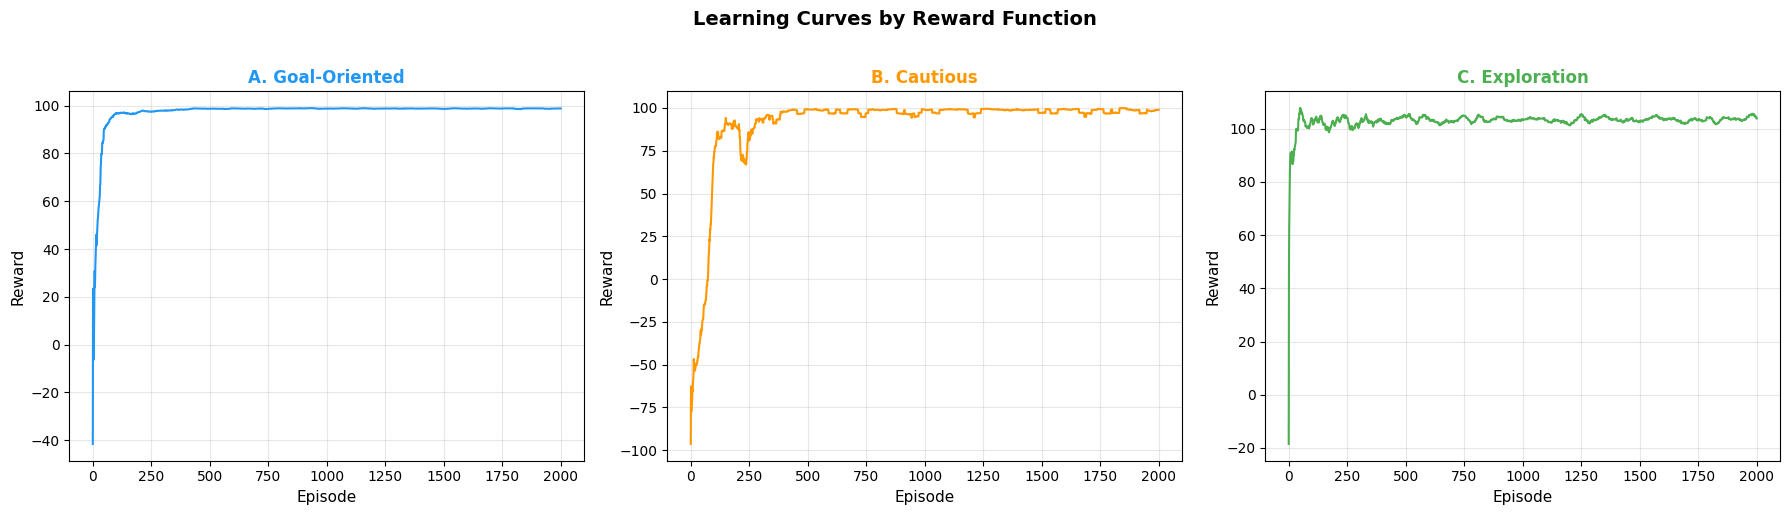

In [5]:
# ============================================
# 학습 곡선 비교
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#FF9800', '#4CAF50']

for idx, (name, data) in enumerate(results.items()):
    rewards = data["rewards"]
    w = 30
    smoothed = [np.mean(rewards[max(0,i-w):i+1]) for i in range(len(rewards))]
    axes[idx].plot(smoothed, color=colors[idx], linewidth=1.5)
    axes[idx].set_xlabel('Episode', fontsize=11)
    axes[idx].set_ylabel('Reward', fontsize=11)
    axes[idx].set_title(name, fontsize=12, fontweight='bold', color=colors[idx])
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Learning Curves by Reward Function', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


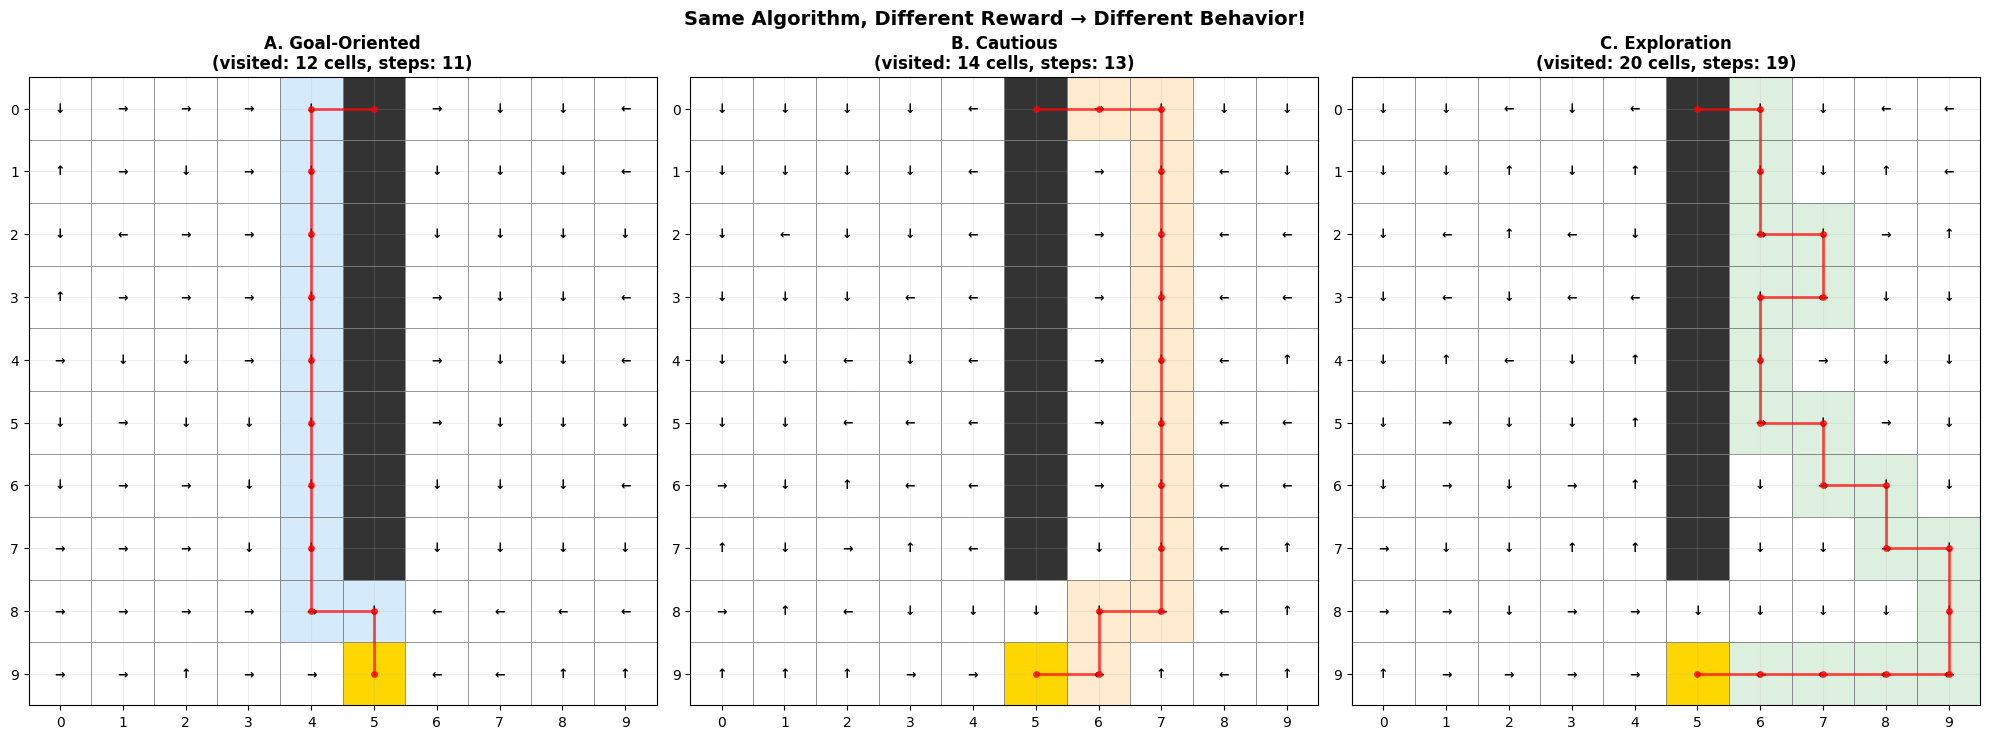

📊 결과 분석:
  A. Goal-Oriented
    → 11스텝, 12칸 방문, ✅ 도달
  B. Cautious
    → 13스텝, 14칸 방문, ✅ 도달
  C. Exploration
    → 19스텝, 20칸 방문, ✅ 도달

💡 같은 미로 + 같은 알고리즘인데 보상만 바꿨을 뿐!
   → AI의 행동은 '보상 함수'가 결정합니다!


In [6]:
# ============================================
# 학습된 정책 비교 (핵심!)
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors_map = ['#2196F3', '#FF9800', '#4CAF50']

for idx, (name, data) in enumerate(results.items()):
    Q = data["Q"]
    policy = np.argmax(Q, axis=2)
    
    # 학습된 정책으로 경로 실행
    state = START
    path = [state]
    visited_cells = {state}
    for _ in range(100):
        action = np.argmax(Q[state[0], state[1]])
        ns, _ = step_base(state, action)
        state = ns
        path.append(state)
        visited_cells.add(state)
        if state == GOAL: break
    
    # 방문한 셀 표시
    special = {}
    for cell in visited_cells:
        if cell not in WALLS and cell != GOAL and cell != START:
            special[cell] = colors_map[idx] + '30'  # 투명하게
    
    draw_maze(axes[idx], f"{name}\n(visited: {len(visited_cells)} cells, steps: {len(path)-1})",
              policy=policy, path=path, special_cells=special)

plt.suptitle('Same Algorithm, Different Reward → Different Behavior!', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📊 결과 분석:")
print("=" * 60)
for name, data in results.items():
    Q = data["Q"]
    state = START; steps = 0; reached = False; visited = {state}
    for _ in range(200):
        a = np.argmax(Q[state[0], state[1]])
        ns, _ = step_base(state, a)
        state = ns; steps += 1; visited.add(state)
        if state == GOAL: reached = True; break
    
    status = "✅ 도달" if reached else "❌ 미도달"
    print(f"  {name}")
    print(f"    → {steps}스텝, {len(visited)}칸 방문, {status}")
print()
print("💡 같은 미로 + 같은 알고리즘인데 보상만 바꿨을 뿐!")
print("   → AI의 행동은 '보상 함수'가 결정합니다!")


## 5단계: 학습 전 vs 학습 후 비교


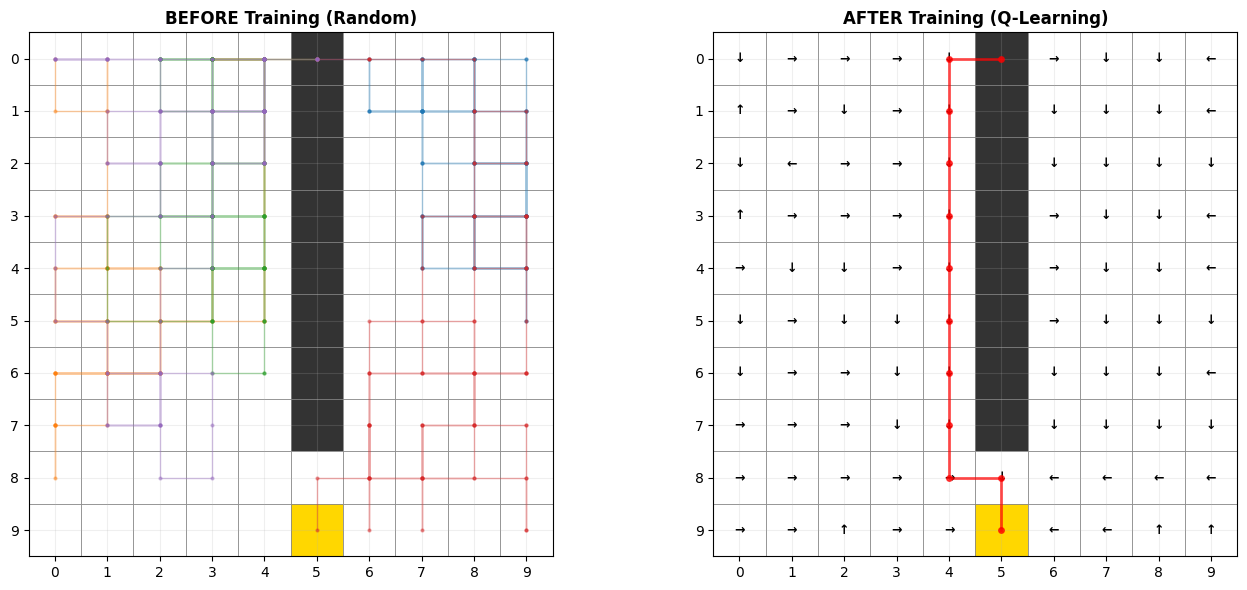

학습 전: 에이전트가 무작위로 헤매며 목표에 도달 못함
학습 후: 벽을 피해 틈을 찾고, 최단 경로로 목표에 도달!

학습 후 경로: 11스텝 (최적에 가까움)


In [7]:
# ============================================
# 학습 전 vs 학습 후 (목표 도달 보상 기준)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 학습 전: 랜덤
np.random.seed(0)
random_paths = []
for _ in range(5):
    state = START; path = [state]
    for _ in range(100):
        a = np.random.randint(4)
        ns, _ = step_base(state, a); state = ns; path.append(state)
        if state == GOAL: break
    random_paths.append(path)

# 여러 랜덤 경로를 하나의 그리드에
draw_maze(axes[0], "BEFORE Training (Random)")
for p in random_paths:
    rows, cols = zip(*p)
    axes[0].plot(cols, rows, 'o-', markersize=2, linewidth=1, alpha=0.4)

# 학습 후
Q_best = results["A. Goal-Oriented"]["Q"]
state = START; learned_path = [state]
for _ in range(100):
    a = np.argmax(Q_best[state[0], state[1]])
    ns, _ = step_base(state, a); state = ns; learned_path.append(state)
    if state == GOAL: break

draw_maze(axes[1], "AFTER Training (Q-Learning)", 
          policy=np.argmax(Q_best, axis=2), path=learned_path)

plt.tight_layout()
plt.show()

print("학습 전: 에이전트가 무작위로 헤매며 목표에 도달 못함")
print("학습 후: 벽을 피해 틈을 찾고, 최단 경로로 목표에 도달!")
print(f"\n학습 후 경로: {len(learned_path)-1}스텝 (최적에 가까움)")


## 6단계: 자율주행 시뮬레이터와의 연결

지금까지 배운 것이 **자율주행 시뮬레이터**에서 어떻게 적용되는지 정리합니다.

| 이 실습 (Q-Learning) | 자율주행 시뮬레이터 (GA) |
|---------------------|----------------------|
| 10×10 격자 미로 | 2D 트랙 (연속 공간) |
| 상/하/좌/우 4행동 | 좌/우 조향 (연속) |
| Q-Table (격자별 Q값) | 신경망 (가중치) |
| Q값 업데이트 (수식) | 유전 알고리즘 (선택/교차/변이) |
| 보상 함수 3종류 비교 | **보상 함수 5종류 선택** |

### 공통된 핵심 원리
1. **보상 함수가 행동을 결정한다** — 이 실습에서 직접 확인!
2. **학습 = 시행착오의 반복** — 처음엔 랜덤, 점점 개선
3. **같은 환경이라도 보상이 다르면 완전히 다른 행동**

### 시뮬레이터에서 확인할 것
- "최대 도달 거리" 보상 → 직진 위주
- "생존 시간" 보상 → 느리지만 안전하게
- "벽 회피" 보상 → 도로 중앙 유지
- **같은 시드로 보상만 바꿔서 비교해보세요!**


## 📝 핵심 정리

### 오늘 배운 것
1. **Q-Learning** = 상태-행동 쌍의 가치(Q값)를 시행착오로 학습
2. **보상 함수** = AI에게 "뭘 잘 했는지" 알려주는 유일한 신호
3. **같은 환경 + 같은 알고리즘이라도 보상만 바꾸면 행동이 완전히 달라짐**
4. 보상 설계가 AI의 행동을 결정 → **AI 정렬(Alignment) 문제**의 핵심!

### AI 학습의 큰 그림
```
           [보상 함수 설계]  ← 사람이 하는 것 (가장 중요!)
                 ↓
[환경] ←→ [에이전트] → [행동] → [보상] → [학습]
                 ↓
           [정책 (행동 규칙)]  ← AI가 학습하는 것
```

> **다음**: `simulator_v4.py`에서 자동차가 보상 함수에 따라 다른 운전 스타일을 학습하는 것을 관찰합시다!
